# 🎓 **Homework #3** 🎓

---

### 👤 **Assigner**:  
**Malkova Ksenia**

### ✍️ **Contacts**:  
- [kemalkova@edu.hse.ru](mailto:kemalkova@edu.hse.ru)

- [@ksu_marshmallow](https://t.me/ksu_marshmallow)

### 🔥 **Deadline** 🔥:
- **11.03.2025**
---

## 📝 Requirements & Tips

- Значения всех параметров (матрицы вероятностей, размерности и т.п.) должны определяться один раз, после чего для вычислений уже используются переменные
- "Хардкодить"числа внутри кода не допускается
- Начальное распределение - **стационарное** (знать, что это)
- Протестировать алгоритмы для $L = 100, 500, 1000$. Добавить защиту от потери точности через `logsumexp` и/или нормализацию (см. учебник Durbin et al)

## 📦 Libraries and Settings

In [1]:
import warnings
from pathlib import Path
from tqdm import tqdm

import numpy as np
from scipy.special import logsumexp
from sklearn.preprocessing import LabelEncoder

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

warnings.simplefilter('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.5
})

In [2]:
DATA_FOLDER = Path.home() / 'PopGen_Models/data/HW3'
SEED = 42

## 📊  Data

In [3]:
symbols = np.arange(1, 7)
states = ['F', 'L']

symbols_encoder = LabelEncoder().fit(symbols)
states_encoder = LabelEncoder().fit(states)

symbols_coded = symbols_encoder.transform(symbols)
states_coded = states_encoder.transform(states)

print(f"Symbols: {symbols_coded} \nStates: {states_coded}")

Symbols: [0 1 2 3 4 5] 
States: [0 1]


# **Main HW Part**

## 🧬 Task 1. Generator

>Для заданных матриц переходных вероятностей $M$ и эмиссионных вероятностей $E$ сгенерировать последовательность σ скрытых состояний и последовательность $\varepsilon$ наблюдений длины $L$. В качестве начального распределения использовать стационарное распределение матрицы $M$ (собственный вектор, соответсвтующий единичному собственному значению).

In [4]:
M = np.array([
    # F, L
    [0.95, 0.05],   # F
    [0.1, 0.9]      # L
])

E = np.array([
    [1/6, 1/6, 1/6, 1/6, 1/6, 1/6],         # F
    [1/10, 1/10, 1/10, 1/10, 1/10, 1/2]     # L
])

### 💡**1.1 Concept**

**Стационарное распределение** - это вектор вероятностей, который остается неизменным после применения матрицы переходных вероятностей. Формально, для матрицы переходных вероятностей 
$M$ стационарное распределение $\pi$ удовлетворяет условию $$\pi = \pi \cdot M$$

Стационарное распределение является *собственным вектором* матрицы $M$, соответствующим собственному значению 1. Оно описывает долгосрочное поведение системы, то есть вероятности нахождения в каждом состоянии после большого числа шагов.

Для нахождения стационарного распределения $\pi$:
1. $\pi = \pi \cdot M$
2. $\sum_i \pi_i = 1$

Наша матрица $M$:
$$M = \begin{pmatrix} 0.95 && 0.05 \\ 0.1 && 0.9 \end{pmatrix}$$

Распишем и решим СЛУ (ищем левый собственный вектор, поэтому транспонировали $M$):
$$
\begin{cases}
    \pi_1 = 0.95 \cdot \pi_1 + 0.1 \cdot \pi_2, && (1) \\
    \pi_2 = 0.05 \cdot \pi_1 + 0.9 \cdot \pi_2, && (2) \\
    \pi_1 + \pi_2 = 1 && (3)
\end{cases}
$$

В $(1)$ подставим $\pi_1$ из $(3)$:
$$
\begin{gather}
    0.05 \cdot \pi_1 - 0.1 \cdot (1 - \pi_1) = 0 \\
    0.15 \cdot \pi_1 = 0.1
\end{gather}
$$

$$
\begin{gather}
    \pi_1 = \frac{2}{3} && \text{ и } && \pi_2 = \frac{1}{3}
\end{gather}
$$

Тогда стационарное распределение $\pi$: $$\pi = [\frac{2}{3} \space \space \space \frac{1}{3}]$$

На основе найденного стационарного распределения $\pi$ генерируем скрытые состояния $\sigma$:
1. Начальное состояние $\sigma_0$ - в соответствие с $\pi$. 
2. Исходя из $E$ и $\sigma_0$ генерируем первое наблюдение $\varepsilon_0$
3. Для каждого шага от $t$ до $L-1$:
    - Переходим из $t$ в $t+1$, исходя из transition matrix $M$
    - Генерируем наблюдение $\varepsilon_t$, исходя из emmission matrix $E$

### 🔧 **1.2 Implementation**

Ищем стационарное распределение:

In [298]:
def get_stationary_distribution(transition_matrix: np.ndarray):
    eig_values, eig_vectors = np.linalg.eig(M.T)

    pi = eig_vectors[:, np.argmax(np.isclose(eig_values, 1))]
    pi /= pi.sum()

    return pi

In [299]:
pi = get_stationary_distribution(M)
pi

array([0.66666667, 0.33333333])

Генерируем скрытые состояния, исходя из стационарного распределения:

In [258]:
def generate_hidden(states_set: np.ndarray,
                    symbols_set: np.ndarray,
                    transition_matrix: np.ndarray,
                    emission_matrix: np.ndarray,
                    pi: np.ndarray,
                    L: int=100,
                    seed: int=None,
                    disable: bool=False):
    """
    Generates a sequence of hidden states and observations from a Hidden Markov Model (HMM)

    Parameters:
        states_set:         Array of state indices (0, 1, ..., num_states-1)
        symbols_set:        Array of observation indices (0, 1, ..., num_symbols-1)
        transition_matrix:  [num_states x num_states] matrix, where entry (i, j) is the probability
                            of transitioning from state i to state j
        emission_matrix:    [num_states x num_symbols] matrix, where entry (i, k) is the probability
                            of emitting observation k from state i
        pi:                 Initial state distribution summing to 1, [num_states, ]
        L:                  Length of the generated sequence (defaults to 100)

    Returns:
        Tuple[np.ndarray, np.ndarray]: 
            - Hidden states sequence of length L (indices from `states_set`)
            - Observed symbols sequence of length L (indices from `symbols_set`)

    UPD: all docstrings are generated with chatgpt because я очень ленивая
    """

    if seed is not None:
        np.random.seed(seed)

    num_states, num_symbols = len(states_set), len(symbols_set)

    # Validations
    assert transition_matrix.shape == (num_states, num_states), "Transition matrix shape mismatch"
    assert emission_matrix.shape == (num_states, num_symbols), "Emission matrix shape mismatch"
    assert pi.shape == (num_states, ), "Initial distribution shape mismatch"

    assert np.allclose(np.sum(transition_matrix, axis=1), 1), "Transition matrix rows must sum to 1"
    assert np.allclose(np.sum(emission_matrix, axis=1), 1), "Emission matrix rows must sum to 1"
    assert np.allclose(np.sum(pi), 1), "Initial distribution must sum to 1"

    # Initialize first hidden state
    initial_state = np.random.choice(states_set, p=pi)
    initial_observation = np.random.choice(symbols_set, p=emission_matrix[initial_state])
    
    hidden_states = [initial_state]
    observations = [initial_observation]
    
    # Generate hidden states and observations according to transition and emission probabilities
    for t in tqdm(range(1, L), colour='GREEN', desc='Generating hidden states and observations...', disable=disable):
        state_prev = hidden_states[t-1]
        
        state_current = np.random.choice(states_set, p=transition_matrix[state_prev])
        observation_current = np.random.choice(symbols_set, p=emission_matrix[state_current])

        hidden_states.append(state_current)
        observations.append(observation_current)
    
    return np.array(hidden_states), np.array(observations)

In [7]:
all_hidden_states, all_observations = [], []
length_seq = [100, 500, 1000]

for l in length_seq:

    print(f"L = {l}")

    hidden_states, observations = generate_hidden(
        states_set=states_coded,
        symbols_set=symbols_coded,
        transition_matrix=M,
        emission_matrix=E,
        pi=pi,
        L=l,
        seed=SEED
    )

    all_hidden_states.append(hidden_states)
    all_observations.append(observations)

L = 100


Generating hidden states and observations...: 100%|██████████| 99/99 [00:00<00:00, 23091.76it/s]


L = 500


Generating hidden states and observations...: 100%|██████████| 499/499 [00:00<00:00, 34902.41it/s]


L = 1000


Generating hidden states and observations...: 100%|██████████| 999/999 [00:00<00:00, 16012.28it/s]


Не знаю, как их нормально изобразить, будет так..

In [8]:
def plot_observations(obs: np.ndarray, title: str=None):    
    matrix = np.zeros((6, len(obs)))    
    for i, sym in enumerate(obs):
        matrix[sym, i] = 1
    
    plt.figure(figsize=(12, 4))
    sns.heatmap(matrix, cmap="Blues", cbar=False, xticklabels=50, yticklabels=range(6))

    if title is not None:
        plt.title(title)
    
    plt.xlabel("Timestep")
    plt.ylabel("Observed Symbol")
    plt.show()

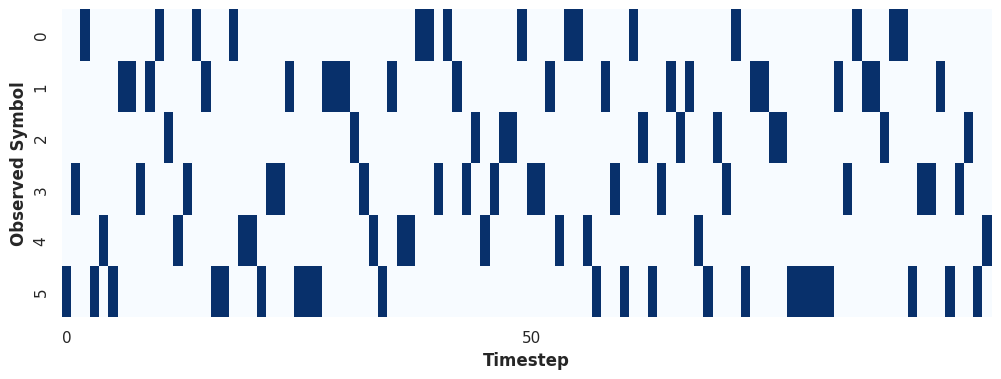

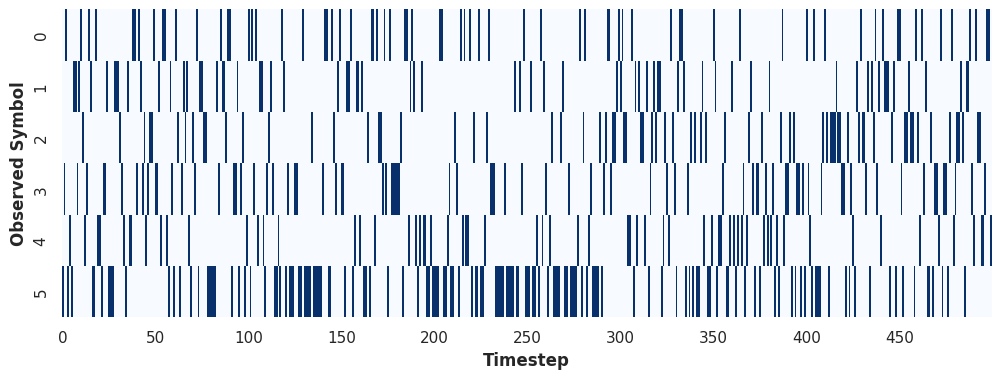

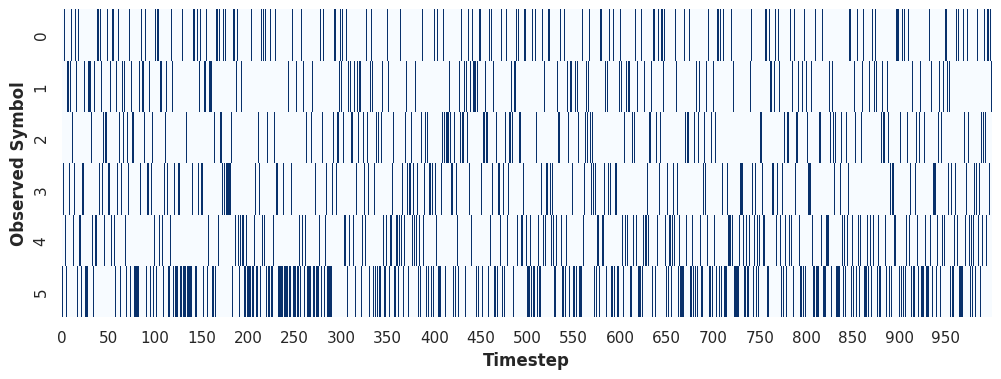

In [9]:
for obs in all_observations:
    plot_observations(obs)

---

## 🧬 Task 2. Viterbi algorithm

> Реализовать алгоритм Витерби: для данных $M$, $E$ и $\varepsilon$ найти $$\sigma_v = \argmax_{\sigma'} P(\sigma', \varepsilon | M, E)$$ Визуализировать результат: построить на графике $\sigma$ и $\sigma_v$ (на оси $x$ позиция, на оси $y$ - номер состояния).

### 💡**2.1 Concept**

Алгоритм Витерби позволяет найти **наиболее вероятный путь**, по которому была сгенерирована наблюдаемая последовательность.

Пусть $v_k(i)$ — наибольшая вероятность пути длиной $i$, заканчивающегося в состоянии $\sigma_k$, при известных наблюдениях $\varepsilon_1, \dotsc, \varepsilon_i$. Тогда для следующего наблюдения $\varepsilon_{i+1}$ вероятность обновляется по формуле:

$$
v_l(i+1) = e_l (\varepsilon_{i+1}) \max_k (v_k(i) \cdot m_{kl}),
$$

где:
- $e_l (\varepsilon_{i+1})$ - вероятность эмиссии наблюдения $\varepsilon_{i+1}$ в состоянии $\sigma_l$,
- $m_{kl}$ - вероятность перехода из состояния $\sigma_k$ в состояние $\sigma_l$.

#### 1. Инициализация $(i=1)$

Для первого наблюдения: 

$$v_k(1) = \pi_k e_k(\varepsilon_1), \quad \forall k$$

где $\pi_k$ - начальное распределение состояний (в нашем случае - стационарное распределение матрицы переходов $M$).  

#### 2. Рекурсия $(i = 2, \dotsc, L)$

На каждом шаге $i$ вычисляем:

$$
\begin{gather}
    v_l(i) = e_l(\varepsilon_i) \max_k (v_k (i-1) \cdot m_{kl}) \\
    \text{ptr}_i(l) = \argmax_k (v_k (i-1) \cdot m_{kl})
\end{gather}
$$

где:
- $m_{kl}$ - вероятность перехода из состояния $\sigma_k$ в $\sigma_l$,
- $e_l (\varepsilon_i)$ - вероятность эмиссии наблюдения $\varepsilon_i$ в состоянии $\sigma_l$,
- $\text{ptr}_i(l)$ - **оптимальное предыдущее состояние**, из которого пришли в $l$ на шаге $i$.

#### 3. Обратный проход $(i = L, \dotsc, 1)$

1. Находим наиболее вероятное конечное состояние:

$$\sigma_{v, L} = \argmax_k v_k (L)$$

2. Восстанавливаем наиболее **оптимальный** путь, двигаясь назад по $\text{ptr}$:
$$\sigma_{v, i-1} = \text{ptr}_i (\sigma_{v, i})$$

### 🔧 **2.2 Implementation**

In [10]:
def viterbi(states_set: np.ndarray,
            transition_matrix: np.ndarray,
            emission_matrix: np.ndarray,
            pi: np.ndarray,
            observations: np.ndarray):
    """
    Implements the Viterbi algorithm to find the most probable hidden state sequence 
    given a sequence of observations.

    Parameters:
        states_set:         Array of state indices (0, 1, ..., num_states-1)
        transition_matrix:  [num_states x num_states] matrix, where entry (i, j) is the probability
                            of transitioning from state i to state j
        emission_matrix:    [num_states x num_symbols] matrix, where entry (i, k) is the probability
                            of emitting observation k from state i
        pi:                 Initial state distribution summing to 1, [num_states, ]
        observations:       Sequence of observed symbols (indices from `symbols_set`)

    Returns:
        np.ndarray: Most probable sequence of hidden states
    """

    L = len(observations)
    num_states = len(states_set)

    # Viterbi table (log probabilities to avoid underflow)
    viterbi_log = np.full((L, num_states), -np.inf)      # Stores log probas of being in state s at time t
    backpointer = np.zeros((L, num_states), dtype=int)   # Stores state k from which we arrived to s

    # 1. Initialization: v_k(1) = π_k * e_k(ε_1)
    viterbi_log[0] = np.log(pi) + np.log(emission_matrix[:, observations[0]])

    # 2. Recursion step:  v_k(t) = e_k(ε_{t}) * max_l [ v_l(t-1) * m_{lk} ]
    for t in tqdm(range(1, L), colour='GREEN', desc='Recursion...'):
        log_probs = viterbi_log[t-1] + np.log(transition_matrix) + np.log(emission_matrix[:, observations[t]])

        # Store the most probable previous state
        backpointer[t] = np.argmax(log_probs, axis=1)

        # Store the best log-probability of this prev state
        viterbi_log[t] = np.max(log_probs, axis=1)

    # 3. Backtracking
    best_path = np.zeros(L, dtype=int)

    # Most probable last state
    best_path[-1] = np.argmax(viterbi_log[-1])

    # For each step we know, from which state we arrived here (most probable)
    for t in range(L-2, -1, -1):
        best_path[t] = backpointer[t+1, best_path[t+1]]

    return best_path

In [11]:
all_best_hidden_path = []

for observations in all_observations:
    print(f"L = {observations.shape[0]}")

    best_hidden_path = viterbi(
        observations=observations,
        pi=pi,
        states_set=states_coded,
        transition_matrix=M,
        emission_matrix=E,
    )

    all_best_hidden_path.append(best_hidden_path)

L = 100


Recursion...: 100%|██████████| 99/99 [00:00<00:00, 38465.59it/s]


L = 500


Recursion...: 100%|██████████| 499/499 [00:00<00:00, 68017.21it/s]


L = 1000


Recursion...: 100%|██████████| 999/999 [00:00<00:00, 56250.63it/s]


In [15]:
image = plt.imread('cat.webp')

def plot_viterbi(predicted_states, title: str=None):
    L = len(predicted_states)
    x = np.arange(L)

    _, ax = plt.subplots(figsize=(12, 6))

    x, predicted_states = np.atleast_1d(x, predicted_states)
    for x0, y0 in zip(x, predicted_states):
        image_box = OffsetImage(image, zoom=0.1)
        ab = AnnotationBbox(image_box, (x0, y0), frameon=False)
        ax.add_artist(ab)
 
    ax.plot(x, predicted_states, alpha=0.3, color='grey', linestyle='--')

    ax.set_xlabel("Time Step")
    ax.set_ylabel("State")
    ax.set_yticks([0, 1])
    ax.set_ylim(-0.5, 1.5)

    if title:
        ax.set_title(title)

    ax.grid(False)

    plt.show()

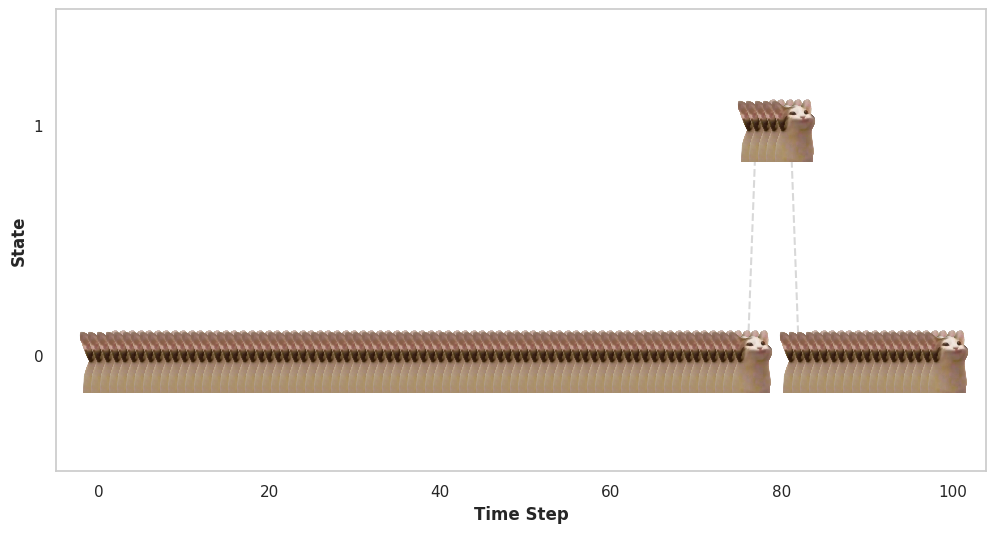

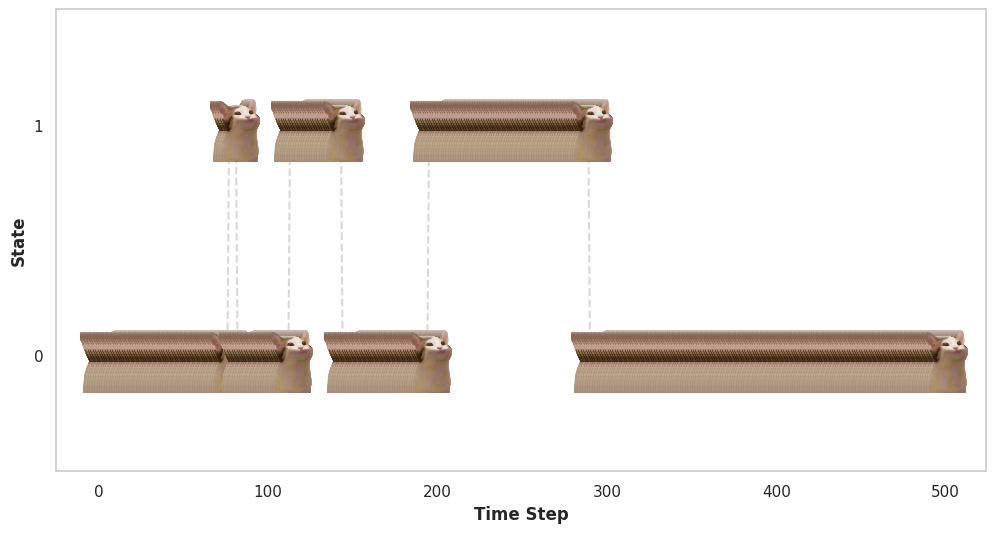

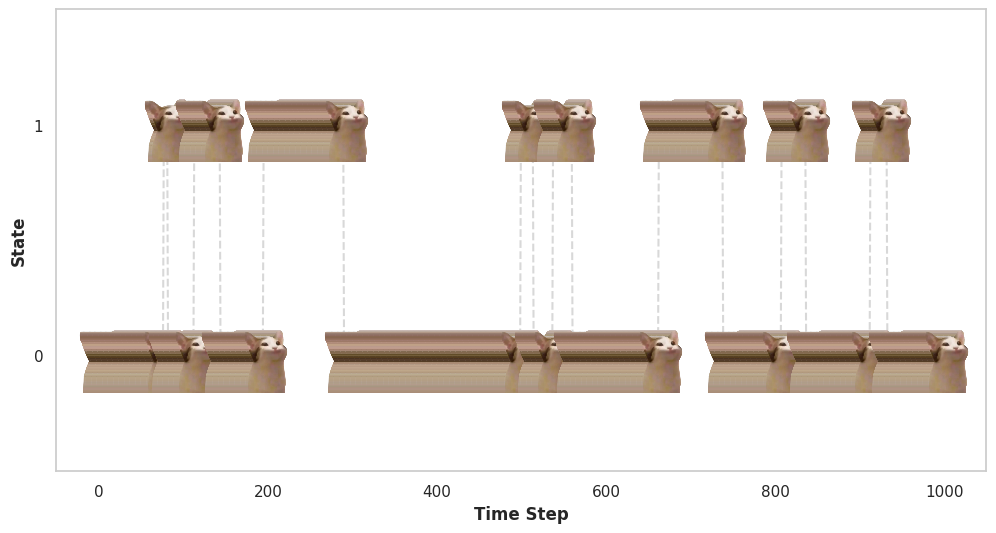

In [16]:
for predicted_states in all_best_hidden_path:
    plot_viterbi(predicted_states)

огонь да

---

## 🧬 Task 3. Forward-backward pass

>Реализовать алгоритмы прямого и обратного хода (особое внимание уделите инициализации алгоритмов!). Вычислить $P(\varepsilon)$ с помощью обоих алгоритмов.

### 💡**3.1 Concept**

Полная вероятность "получить" последовательность наблюдений $\varepsilon$ - сумма вероятностей по всем возможным путям $\sigma'$ сгенерировать эту последовательность:
$$
P(\varepsilon) = \sum_{\sigma'} P(\varepsilon, \sigma')
$$


#### **I. Forward-алгоритм**
Определим forward-term $f_k(i)$ как вероятность наблюдать первые $i$ символов последовательности, если $i$-е скрытое состояние равно $k$:

$$f_k(i) = (\varepsilon_1, \dotsc, \varepsilon_i, \sigma_i = k)$$

Основное отличие от Витерби-алгоритма состоит в том, что в forward-алгоритме мы используем сумму, а не максимум в шаге рекурсии.

**1. Инициализация** $(i=1)$:

Для первого шага вычисляем:

$$f_k(1) = \pi_k e_k(\varepsilon_1), \quad \forall k$$

где $\pi_k$ - это начальная вероятность быть в состоянии $k$ (стационарное распределение).

**2. Рекурсия** $(i = 2, \dotsc, L)$:

Для каждого последующего шага вычисляем:

$$f_l(i) = e_l (\varepsilon_i) \sum_k \big[ f_k (i-1) m_{kl} \big],$$

где:
- $m_{kl}$ - вероятность перехода из состояния $\sigma_k$ в $\sigma_l$,
- $e_l (\varepsilon_i)$ - вероятность эмиссии наблюдения $\varepsilon_i$ в состоянии $\sigma_l$.

**3. Остановка**

После вычислений для всех шагов $L$ можем найти полную вероятность наблюдать послдедовательность $\varepsilon$:

$$P(\varepsilon) = \sum_k f_k(L)$$

#### **II. Backward-алгоритм**

Определим backward-term $b_k(i)$ как вероятность увидеть оставшуюся часть последовательности $\varepsilon_{i+1}, \dotsc, \varepsilon_L$, если в момент $i$ мы в состоянии $\sigma_i = k$:

$$b_k(i) = P(\varepsilon_{i+1}, \dotsc, \varepsilon_L | \sigma_i = k)$$

**1. Инициализация** $(i=L)$:  
Для последнего шага, поскольку после $L$ нет больше наблюдений, вероятность того, что остаток последовательности будет наблюдаться в любом состоянии, равна 1:

$$b_k(L) = 1, \quad \forall k$$

**2. Рекурсия** $(i=L-1, \dotsc, 1)$:

Для каждого предыдущего шага вычисляем:

$$b_k(i) = \sum_l \big[ m_{kl} e_l (\varepsilon_{i+1}) b_l (i+1) \big],$$

где:
- $m_{kl}$ — вероятность перехода из состояния $\sigma_k$ в состояние $\sigma_l$,
- $e_l (\varepsilon_{i+1})$ — вероятность эмиссии символа $\varepsilon_{i+1}$ в состоянии $\sigma_l$,
- $b_l(i+1)$ — backward-вероятность для следующего шага.

**3. Остановка**

Для вычисления полной вероятности сгенерировать всю последовательность наблюдений - смотрим на backward-вероятности на "первых" позициях:

$$P(\varepsilon) = \sum_k \big[ \pi_k e_k(\varepsilon_1) b_k (1) \big]$$

### 🔧 **3.2 Implementation**

In [ ]:
def forward_algorithm(states_set: np.ndarray,
                      transition_matrix: np.ndarray,
                      emission_matrix: np.ndarray,
                      pi: np.ndarray,
                      observations: np.ndarray,
                      disable: bool=False):
    """
    Computes the forward probabilities f_t(s) using the Forward algorithm.

    Parameters:
        states_set:         Array of state indices (0, 1, ..., num_states-1)
        transition_matrix:  [num_states x num_states] matrix, where entry (i, j) is the probability
                            of transitioning from state i to state j
        emission_matrix:    [num_states x num_symbols] matrix, where entry (i, k) is the probability
                            of emitting observation k from state i
        pi:                 Initial state distribution summing to 1, [num_states, ]
        observations:       Sequence of observed symbols (indices from `symbols_set`)

    Returns:
        np.ndarray: Forward probability matrix (log scale) of shape (L, N).
        float:      Log-probability P(ε) computed using the forward algorithm.
    """

    L = len(observations)
    num_states = len(states_set)

    # Forward matrix in log-space (to avoid underflow)
    forward_log = np.full((L, num_states), -np.inf)     # Stores log probas of being in state s at time t

    # 1. Initialization: f_k(1) = π_k * e_k(ε_1)
    forward_log[0] = np.log(pi) + np.log(emission_matrix[:, observations[0]])

    # 2. Recursion step: f_k(t) = e_k(ε_t) * \sum_l [ f_l (t-1) * m_lk ]
    for t in tqdm(range(1, L), colour='MAGENTA', desc='Forward pass...', disable=disable):
        # почему-то с таким подсчетом не сходится... различие в десятые-сотые, но что-то странное
        # можете раскомментить это, и закоментить цикл - посмотреть, но я опустила руки
        
        # forward_log[t] = np.log(emission_matrix[:, observations[t]]) + \
        #                  logsumexp(forward_log[t-1] + np.log(transition_matrix), axis=1)
        
        for s in states_set:
            forward_log[t, s] = np.log(emission_matrix[s, observations[t]]) + \
                                logsumexp(forward_log[t-1] \
                                          + np.log(transition_matrix[:, s]))

    # 3. Stop: P(ε) = \sum_k {f_k(L)}
    log_P_obs = logsumexp(forward_log[-1])

    return forward_log, log_P_obs

In [18]:
def backward_algorithm(states_set: np.ndarray,
                       transition_matrix: np.ndarray,
                       emission_matrix: np.ndarray,
                       observations: np.ndarray,
                       disable: bool=False):
    """
    Computes the backward probabilities b_t(s) using the Backward algorithm.

    Parameters:
        states_set:         Array of state indices (0, 1, ..., num_states-1)
        transition_matrix:  [num_states x num_states] matrix, where entry (i, j) is the probability
                            of transitioning from state i to state j
        emission_matrix:    [num_states x num_symbols] matrix, where entry (i, k) is the probability
                            of emitting observation k from state i
        observations:       Sequence of observed symbols (indices from `symbols_set`)

    Returns:
        np.ndarray: Backward probability matrix (log scale) of shape (L, N).
        float: Log-probability P(ε) computed using the backward algorithm.
    """

    L = len(observations)
    N = len(states_set)

    # Backward matrix in log-space (to avoid underflow)
    backward_log = np.full((L, N), -np.inf)     # Stores log probas of being in state s at time t

    # 1. Initialization: b_k(L) = 1  --> log( b_k(L) ) = 0
    backward_log[-1] = 0

    # 2. Recursion step: b_k(t) = \sum_l [ m(kl) * e(ε_{t+1}) * b_l(t+1) ]
    for t in tqdm(range(L-2, -1, -1), colour='CYAN', desc='Backward pass...', disable=disable):
        backward_log[t] = logsumexp(np.log(transition_matrix) \
                                    + np.log(emission_matrix[:, observations[t+1]]) \
                                    + backward_log[t+1], 
                                    axis=1)

    # 3. Stop: P(ε) = \sum_k [ π_k * e_k(ε_1) * b_k(1) ]
    log_P_obs = logsumexp(np.log(pi) \
                          + np.log(emission_matrix[:, observations[0]]) \
                          + backward_log[0])

    return backward_log, log_P_obs

In [19]:
for observations in all_observations:
    print(f"L = {len(observations)}")

    forward_log, log_P_forward = forward_algorithm(states_set=states_coded,
                                                   transition_matrix=M,
                                                   emission_matrix=E,
                                                   pi=pi,
                                                   observations=observations)
    
    backward_log, log_P_backward = backward_algorithm(states_set=states_coded,
                                                      transition_matrix=M,
                                                      emission_matrix=E,
                                                      observations=observations)

    print(f"Log P(ε) from Forward: {log_P_forward:.4f}")
    print(f"Log P(ε) from Backward: {log_P_backward:.4f}")
    print('-'*100)

L = 100


Backward pass...: 100%|██████████| 99/99 [00:00<00:00, 16682.18it/s]


Log P(ε) from Forward: -178.2200
Log P(ε) from Backward: -178.2200
----------------------------------------------------------------------------------------------------
L = 500


Backward pass...: 100%|██████████| 499/499 [00:00<00:00, 19508.21it/s]


Log P(ε) from Forward: -861.7509
Log P(ε) from Backward: -861.7509
----------------------------------------------------------------------------------------------------
L = 1000


Backward pass...: 100%|██████████| 999/999 [00:00<00:00, 19738.60it/s]

Log P(ε) from Forward: -1730.2016
Log P(ε) from Backward: -1730.2016
----------------------------------------------------------------------------------------------------


---

## 🧬 Task 4. A posteriory decoding 

>Реализовать апостериорное декодирование. Визуализировать результат: построить график $P(\text{state}_0 | \varepsilon) (l)$

### 💡**4.1 Concept**

Апостериорное декодирование позволяет вычислить **наиболее вероятное состояние на каждом шаге** $t$, учитывая как предыдущие, так и последующие наблюдения.

Для каждого шага $t$ апостериорное декодирование позволяет найти **апостериорную вероятность** состояния $\sigma_t = k$:
$$
    P(\sigma_t = k | \varepsilon) = \frac{P(\varepsilon | \sigma_t = k) \cdot P (\sigma_t = k)}{P(\varepsilon)},
$$

где
- $P(\sigma_t = k | \varepsilon)$ - апостериорная вероятность того, что в момент времени $t$ система находится в состоянии $k$, учитывая всю последовательность наблюдений $\varepsilon$
- $P(\varepsilon | \sigma_t = k)$ - вероятность наблюдать последовательность $\varepsilon$ при условии, что в момент времени $t$ состояние равно $k$ (это вычисляется с использованием алгоритма forward- / backward-)
- $P(\sigma_t = k)$ - **априорная** вероятность того, что система находится в состоянии $k$
- $P(\varepsilon)$ - полная вероятность наблюдат последовательность наблдюений $\varepsilon$ (нормализующая константа - гарантирует, что все вероятности суммируются до 1; можно вычислить через сумму по всем состояниям для всех возможных путей, т.е. через forward- или backward-алгоритм).

Можем расписать эту вероятность через forward- и backward-вероятности:
$$
\begin{gather}
    \begin{cases}
    f_k(t) = P(\varepsilon_1, \dotsc, \varepsilon_t, \sigma_t=k) = P(\varepsilon_1, \dotsc, \varepsilon_t | \sigma_t=k) \cdot P(\sigma_t=k)\\
    b_k(t) = P(\varepsilon_{t+1}, \dotsc, \varepsilon_L | \sigma_t = k)
    \end{cases}
    && \to && f_k(t) \cdot b_k(t) = P(\varepsilon | \sigma_t=k) \cdot P(\sigma_t=k)
\end{gather}
$$

То есть числитель можем заменить на произведение forward- и backward-вероятностей:
$$
    P(\sigma_t = k | \varepsilon) = \frac{f_k(t) \cdot b_k(t)}{P(\varepsilon)}
$$

**Алгоритм**
1. Для каждого шага $t$ мы вычисляем forward- и backward- вероятности ($f_k(t)$ и $b_k(t)$ соответственно). Они отражают, насколько вероятно наблюдать всю последовательность наблюдений, если в момент времени $t$ система находится в состоянии $k$.
2. Для каждого состояния $k$ на каждом шаге $t$ вычисляем апостериорную вероятность: $$P(\sigma_t = k | \varepsilon) = \frac{f_k(t) \cdot b_k (t)}{P(\varepsilon)}$$
3. Итоговую нормализующую константу $P(\varepsilon)$ можно вычислить через backward- или forward-алгоритмы:
$$
\begin{gather}
    P(\varepsilon) = \sum_k f_k (L) && \text{(forward-algo)} \\
    P(\varepsilon) = \sum_k \pi_k e_k(\varepsilon_1)b_k(1) && \text{(backward-algo)} \\
\end{gather}
$$

### 🔧 **4.2 Implementation**

In [20]:
def posterior_decoding(states_set: np.ndarray, 
                       transition_matrix: np.ndarray, 
                       emission_matrix: np.ndarray, 
                       pi: np.ndarray, 
                       observations: np.ndarray):
    """
    Computes the posterior probabilities P(σ_i | ε) using the forward and backward probabilities.

    Parameters:
        states_set:         Array of state indices (0, 1, ..., num_states-1)
        transition_matrix:  [num_states x num_states] matrix, where entry (i, j) is the probability
                            of transitioning from state i to state j
        emission_matrix:    [num_states x num_symbols] matrix, where entry (i, k) is the probability
                            of emitting observation k from state i
        pi:                 Initial state distribution summing to 1, [num_states, ]
        observations:       Sequence of observed symbols (indices from `symbols_set`)

    Returns:
        np.ndarray: Posterior probability matrix (log scale) of shape (L, num_states).
    """

    # Step 1: Calculate forward and backward probabilities
    forward_log, P_obs = forward_algorithm(states_set=states_set,
                                           transition_matrix=transition_matrix,
                                           emission_matrix=emission_matrix,
                                           pi=pi,
                                           observations=observations)
    
    backward_log, _ = backward_algorithm(states_set=states_set,
                                         transition_matrix=transition_matrix,
                                         emission_matrix=emission_matrix,
                                         observations=observations)

    # Step 2: Calculate posterior probabilities for each state at each time step
    # P(σ_i = k | ε) = f_k(i) * b_k(i) / P(ε), but using log scale:
    posterior_log = forward_log + backward_log - P_obs

    return posterior_log

In [21]:
all_posterior_prob = []

for observations in all_observations:
    print(f"L = {len(observations)}")

    posterior_log = posterior_decoding(
        states_set=states_coded,
        transition_matrix=M,
        emission_matrix=E,
        pi=pi,
        observations=observations
    )

    posterior_prob = np.exp(posterior_log)
    all_posterior_prob.append(posterior_prob)

L = 100


Backward pass...: 100%|██████████| 99/99 [00:00<00:00, 16814.58it/s]


L = 500


Backward pass...: 100%|██████████| 499/499 [00:00<00:00, 13041.05it/s]


L = 1000


Backward pass...: 100%|██████████| 999/999 [00:00<00:00, 17397.10it/s]


In [ ]:
def plot_state_proba(posterior_prob, observations, title: str = None):
    num_states = posterior_prob.shape[1]

    plt.figure(figsize=(14, 6))

    colors = plt.cm.get_cmap("tab10", num_states)
    for state_idx in range(num_states):
        plt.plot(range(len(observations)), posterior_prob[:, state_idx], label=f"State {state_idx}",
                 color=colors(state_idx), linewidth=2, linestyle='-')
    
    if title:
        plt.title(title)
    
    plt.xlabel(r"Time Step $t$")
    plt.ylabel(r"$P(\sigma_t | \varepsilon)$")
    plt.legend(loc='upper right')
    
    plt.show()

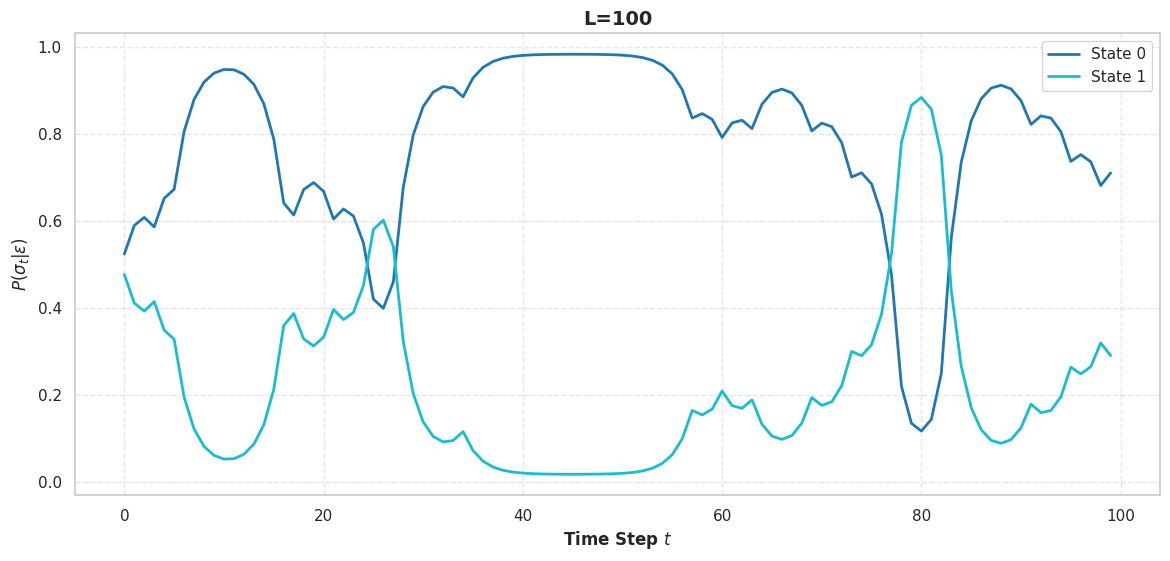

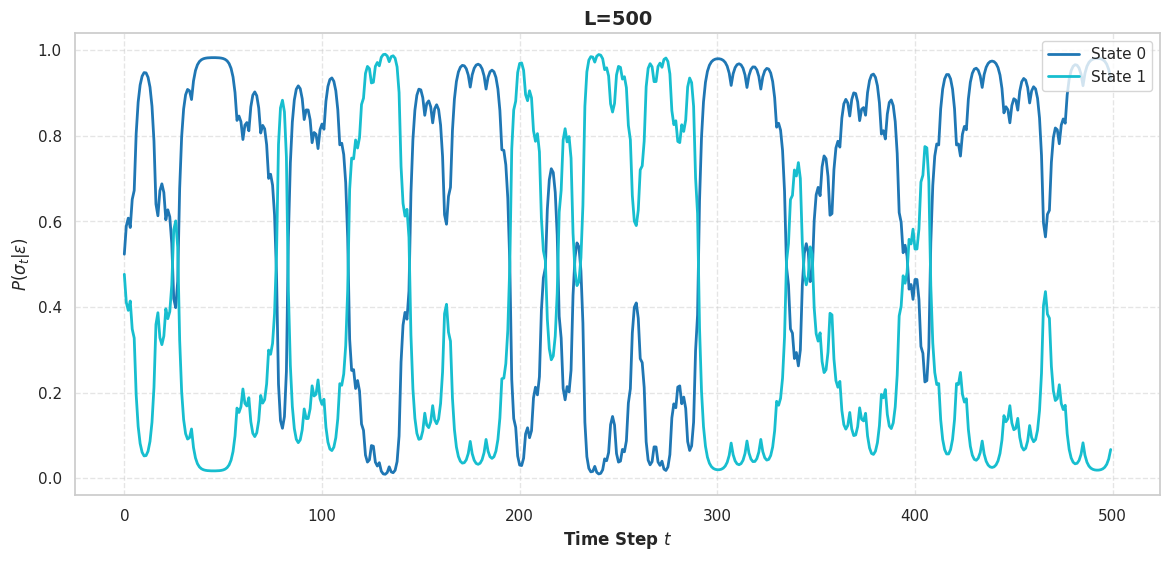

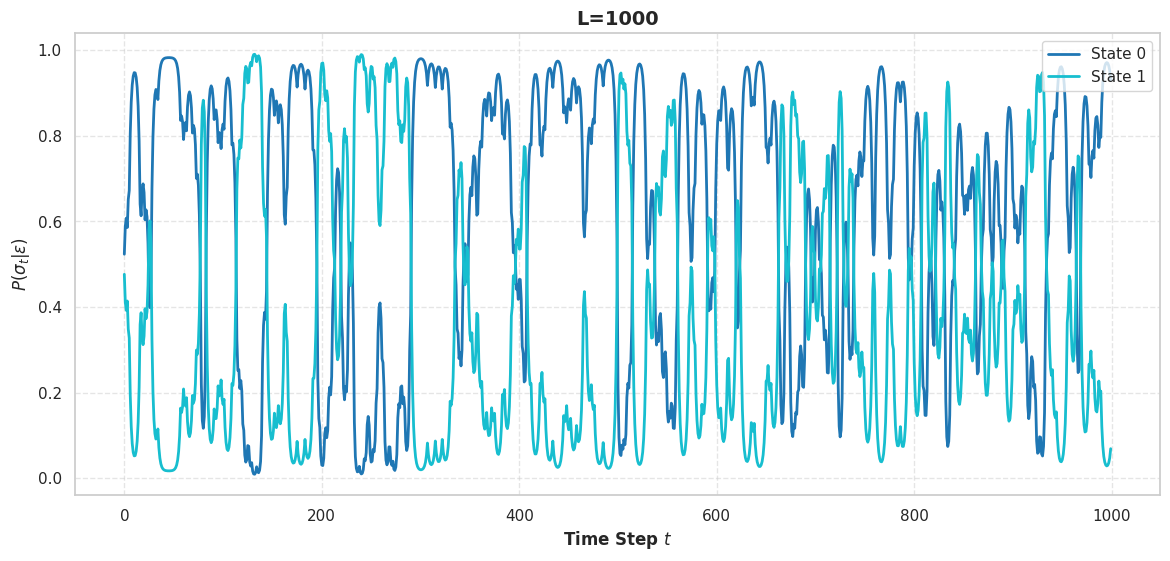

In [25]:
for observations, posterior_prob in zip(all_observations, all_posterior_prob):
    plot_state_proba(posterior_prob, observations, title=f"L={len(observations)}")

---

## 🧬 Task 5. Baum-Welch algorithm
>Реализовать алгоритм Баума-Велша

### 💡**5.1 Concept**

Алгоритм **Баума-Велша** - **итеративный метод оценки параметров** HMM, когда у нас есть только наблюдаемые данные $\varepsilon$, но неизвестны параметры:  
- **матрица переходов** $M = \{m_{kl}\} $,
- **матрица эмиссий** $E = \{e_k(\varepsilon)\}$
- **начальное распределение** $\pi$

Этот алгоритм является частным случаем **EM-алгоритма (Expectation-Maximization)**, который чередует два шага:  

#### I. **Expectation (E-шаг)**
На этом шаге находим *апостериорные* вероятности нахождения в состояниях и переходов между состояниями на основе текущих параметров модели. Для каждой последовательности $\varepsilon^j$ ($j = 1, \dotsc, n$):
1. Forward-backward алгоритм:
  - Вычисляем forward-вероятности $f_k^j(t)$ - вероятность наблюдать последовательность до шага $t$ и находится в состоянии $k$ на шаге $t$
  - Вычисляем backward-вероятности $b_k^j(t)$ - вероятность наблюдать последовательность после шага $t$ при условии, что находимся в состоянии $k$ на шаге $t$
2. Апостериорные вероятности:
  - Вероятность нахождения в состоянии $k$ на шаге $t$ для последовательности $e^j$: $$\gamma^j_k(t) = P(\sigma_t = k | \varepsilon^j) = \frac{f_k^j(t) \cdot b_k^j(t)}{P(\varepsilon^j)}$$
  - Вероятность перехода $k \to l$ на шаге $t$ для последовательности $e^j$: $$\xi^j_{kl}(t) = P(\sigma_t = k, \sigma_{t+1} = l | \varepsilon^j) = \frac{f_k^j(t) \cdot b_l^j(t+1) \cdot m_{kl} \cdot e_l(\varepsilon^j_{t+1}) }{P(\varepsilon^j)}$$
3. Агрегация по всем последовательностям - суммируем $\gamma^j_k(t)$ и $\xi^j_{kl}(t)$ по всем последовательностям: $$\gamma_k(t) = \sum_{j=1}^n \gamma^j_k(t), \quad \quad \xi_{kl}(t) = \sum_{j=1}^n \xi^j_{kl}(t)$$

#### II. **Maximization (M-шаг)**
На этом шаге обновляем параметры модели на основе апостериорных вероятностей, вычисленных на E-шаге (максимизируя вероятность того, что мы наблюдаем)

1. Обновляем **transition matrix $M$**. Оцениваем вероятность прехода $k \to l$ как ожидаемое число таких переходов относительно общего числа пребываний в состоянии $k$
$$
  \hat{m}_{kl} = \frac{\sum_{t=1}^{L-1} \xi_{kl}(t)}{\sum_{i=1}^{L-1} \gamma_k(t)}
$$

2. Обновляем **emission matrix $E$**. Оцениваем вероятность генерации $\varepsilon=x$ состоянием $k$ как долю раз, когда hmm была в $k$ и выплюнула символ $x$
$$
  \hat{e}_k(x) = \frac{\sum_{t: \varepsilon_t = x} \gamma_k(t)}{\sum_{t=1}^{L} \gamma_k(t)}
$$

3. Обновляем **начальное распределение $\pi$** (вероятность быть в $k$ на первом шаге)
$$
  \hat{\pi}_k = \gamma_k(1)
$$

#### **Алгоритм**
1. **Инициализация** - задаем начальные значения параметров $M$, $E$, $\pi$ (случайные или априорные оценки)
2. **Итерации** - чередуем E- и M-шаги, пока не выполнится один из критерий останова:
    - **E-шаг** - для каждой последовательности вычисляем $\gamma_k^j(t)$ и $\xi_{kl}^{j}(t)$ с помощью forward-backward алгоритмов, затем агрегируем (суммируем) их
    - **M-шаг** - обновляем параметры $M$, $E$, $\pi$ на основе $\gamma_k(t)$ и $\xi_{kl}(t)$
3. **Остановка**. Критерии останова (возможные):
    - Разница между лог-правдоподобиями на соседних итерациях $\Delta \log P(\varepsilon)$ меньше какого-то заданного нами порога
    - Достигнуто максимальное число итераций

**Возможные улучшения:**
- Добавление псевдочастот (Laplace smoothing) для избежания нулевых вероятностей:
$$
\begin{gather}
    \hat{m}_{kl} = \frac{\sum_{t=1}^{L-1} \xi_{kl}(t) + r_{kl}}{\sum_{i=1}^{L-1} \gamma_k(t) + \sum_l r_{kl}}\\
    \hat{e}_k(x) = \frac{\sum_{t: \varepsilon_t = x} \gamma_k(t) + r_k(x)}{\sum_{t=1}^{L} \gamma_k(t) + \sum_x r_k(x)}
\end{gather}
$$
где $r_{kl}$ и $r_k(x)$ - небольшие положительные псевдочастоты
- Если есть несколько обучающих последовательностей $\varepsilon^j$, усредняем $\xi_{kl} (t)$ и $\gamma_k (t)$ по ним. 
- Можно запускать алгоритм с разных начальных параметров и выбирать лучшее по правдоподобию.

### 🔧 **5.2 Implementation**

In [327]:
def generate_hiddens(num_sequences, sequence_length, states_set, symbols_set, transition_matrix, emission_matrix, pi, seed):
    if seed is not None:
        np.random.seed(seed)

    hidden_states, observations = zip(*[
        generate_hidden(states_set, symbols_set, transition_matrix, emission_matrix, pi, sequence_length, seed, disable=True)
        for _ in range(num_sequences)
    ])

    hidden_states = np.array(hidden_states)  # [num_sequences, sequence_length]
    observations = np.array(observations)    # [num_sequences, sequence_length]
    return hidden_states, observations

In [328]:
def get_prior(hidden_states: np.ndarray,
              observations: np.ndarray,
              states_set: np.ndarray,
              symbols_set: np.ndarray):
    """
    Estimates initial parameters of an HMM based on generated data

    Parameters:
        num_sequences:      Number of observation sequences to be generated
        sequence_length:    Length of each observation sequence
        states_set:         Array of state indices (0, 1, ..., num_states-1)
        symbols_set:        Array of symbols indices (0, 1, ..., num_symbols-1)
        transition_matrix:  [num_states x num_states] matrix of prior transition probabilities
        emission_matrix:    [num_states x num_symbols] matrix of prior emission probabilities
        pi:                 [num_states, ] vector of prior initial state distripution
        seed:               Random seed for initialization

    Returns:
        pi_estimated:       Estimation of Initial state distribution [num_states, ]
        M_estimated:        Estimation of Transition matrix [num_states x num_states]
        E_estimated:        Estimation of Emission matrix [num_states x num_symbols]
    """

    # Estimation of Transition matrix
    M_estimated = np.zeros((len(states_set), len(states_set)))
    np.add.at(M_estimated, 
              (hidden_states[:, :-1].ravel(), hidden_states[:, 1:].ravel()),
               1)
    M_estimated /= M_estimated.sum(axis=1, keepdims=True)

    # Estimation of Initial state distribution
    pi_estimated = get_stationary_distribution(M_estimated)

    # Estimation of Emission matrix
    E_estimated = np.zeros((len(states_set), len(symbols_set)))
    np.add.at(E_estimated, 
              (hidden_states.ravel(), observations.ravel()),
               1)
    E_estimated /= E_estimated.sum(axis=1, keepdims=True)

    return pi_estimated, M_estimated, E_estimated

In [ ]:
def baum_welch(states_set: np.ndarray,
               observations: np.ndarray,
               transition_matrix: np.ndarray=None,
               emission_matrix: np.ndarray=None,
               pi: np.ndarray=None,
               max_iter: int=100,
               tol: float=1e-6,
               seed: int=None):
    """
    Estimates the parameters of an HMM using the Baum-Welch algorithm.

    Parameters:
        states_set:         Array of state indices (0, 1, ..., num_states-1)
        symbols_set:        Array of symbols indices (0, 1, ..., num_symbols-1)
        observations:       Sequence of observed symbols (indices from `symbols_set`)
        transition_matrix:  [num_states x num_states] matrix of prior transition probabilities
        emission_matrix:    [num_states x num_symbols] matrix of prior emission probabilities
        pi:                 [num_states, ] vector of prior initial state distripution
        max_iter:           Maximum number of iterations
        tol:                Tolerance for convergence
        seed:               Random seed for initialization

    Returns:
        transition_matrix:  [num_states x num_states] matrix of transition probabilities
        emission_matrix:    [num_states x num_symbols] matrix of emission probabilities
        pi:                 Initial state distribution [num_states, ]
    """

    if seed is not None:
        np.random.seed(seed)

    num_states, num_symbols = emission_matrix.shape
    num_sequences, sequence_length = observations.shape

    log_likelihood = -np.inf

    for iter in tqdm(range(max_iter), desc='Baum-Welch Training', colour='GREEN'):
        
        # E-step: Compute forward and backward probabilities
        forward_log = np.zeros((num_sequences, sequence_length, num_states))
        backward_log = np.zeros((num_sequences, sequence_length, num_states))
        log_P_obs = np.zeros(num_sequences)

        for j in range(num_sequences):
            forward_log[j], log_P_obs[j] = forward_algorithm(
                states_set=states_set,
                transition_matrix=transition_matrix,
                emission_matrix=emission_matrix,
                pi=pi,
                observations=observations[j],
                disable=True
            )
            backward_log[j], _ = backward_algorithm(
                states_set=states_set,
                transition_matrix=transition_matrix,
                emission_matrix=emission_matrix,
                observations=observations[j],
                disable=True
            )

        # Compute posterior probabilities
        posterior_log = forward_log + backward_log - log_P_obs[:, None, None]  # P(σ_t = k | ε^j)

        xi = np.zeros((num_sequences, sequence_length-1, num_states, num_states)) # P(σ_t = k, σ_{t+1} = l | ε^j)
        for j in range(num_sequences):
            for t in range(sequence_length-1):
                xi[j, t] = np.exp(forward_log[j, t, :, None] \
                                  + np.log(transition_matrix) \
                                  + np.log(emission_matrix[:, observations[j, t+1]]) \
                                  + backward_log[j, t+1, None, :] \
                                  - log_P_obs[j])

        # M-step: Update parameters
        new_transition_matrix = np.sum(xi, axis=(0, 1)) / np.sum(np.exp(posterior_log[:, :-1]), axis=(0, 1), keepdims=True)
        new_transition_matrix =/ new_transition_matrix.sum(axis=1, keepdims=True)
    
        new_pi = get_stationary_distribution(new_transition_matrix)

        new_emission_matrix = np.zeros((num_states, num_symbols))
        for k in range(num_states):
            for v in range(num_symbols):
                mask = (observations == v)
                new_emission_matrix[k, v] = np.sum(np.exp(posterior_log[mask, k])) / np.sum(np.exp(posterior_log[:, k]))
        new_emission_matrix /= new_emission_matrix.sum(axis=1, keepdims=True)

        # Check for convergence
        if np.mean(log_P_obs) - log_likelihood < tol:
            print(f'Converged at iteration {iter+1}')
            break

        log_likelihood = np.mean(log_P_obs)

        # Update parameters
        # возможно 
        transition_matrix = new_transition_matrix
        emission_matrix = new_emission_matrix
        pi = new_pi

    return transition_matrix.T, emission_matrix, pi

In [ ]:
num_sequences = 300
all_M, all_E, all_pi = [], [], []

for length in length_seq:
    hidden_states, observations = generate_hiddens(num_sequences=num_sequences,
                                                   sequence_length=length,
                                                   states_set=states_coded,
                                                   symbols_set=symbols_coded,
                                                   transition_matrix=M,
                                                   emission_matrix=E,
                                                   pi=pi,
                                                   seed=SEED)
    
    pi_estimated, M_estimated, E_estimated = get_prior(hidden_states=hidden_states,
                                                       observations=observations,
                                                       states_set=states_coded,
                                                       symbols_set=symbols_coded)
    
    transition_matrix_new, emission_matrix_new, pi_new = baum_welch(states_set=states_coded,
                                                                    observations=observations,
                                                                    transition_matrix=M_estimated,
                                                                    emission_matrix=E_estimated,
                                                                    pi=pi_estimated,
                                                                    max_iter=1000,
                                                                    tol=1e-6,
                                                                    seed=SEED)
    
    all_M.append(transition_matrix_new)
    all_E.append(emission_matrix_new)
    all_pi.append(pi_new)

Baum-Welch Training:   0%|          | 2/1000 [00:15<2:06:56,  7.63s/it]

Converged at iteration 3



Baum-Welch Training:   0%|          | 1/1000 [00:23<6:29:38, 23.40s/it]

In [363]:
def plot_matrices(matrix_eval: list, 
                  matrix_gt: np.ndarray, 
                  lengthes: list,
                  title: str,
                  ylabel: str=None,
                  xlabel: str=None):
    
    fig, axs = plt.subplots(1, len(matrix_eval) + 1, figsize=(22, 6))

    for i, (m, l) in enumerate(zip(matrix_eval + [matrix_gt], lengthes + ['real'])):
        ax_title = f"Length={l}" if isinstance(l, int) else l
        cbar = not isinstance(l, int)

        heatmap = sns.heatmap(m,
                            cmap="Blues", cbar=cbar,
                            linecolor="black", linewidths=0.6,
                            vmin=0, vmax=1,
                            annot=True, fmt=".2f",
                            ax=axs[i])
        
        axs[i].set_title(ax_title)

        if xlabel is not None:
            axs[i].set_xlabel(xlabel)
        
        if ylabel is not None and i == 0:
            axs[i].set_ylabel(ylabel)
        
        if cbar:
            heatmap.collections[0].colorbar.set_label("Probability", fontsize=12)

    fig.suptitle(title, fontsize=20, fontweight='bold')
    plt.show()

In [364]:
all_M

[array([[[0.9885106 ],
         [0.0114894 ]],
 
        [[0.84983381],
         [0.15016619]]])]

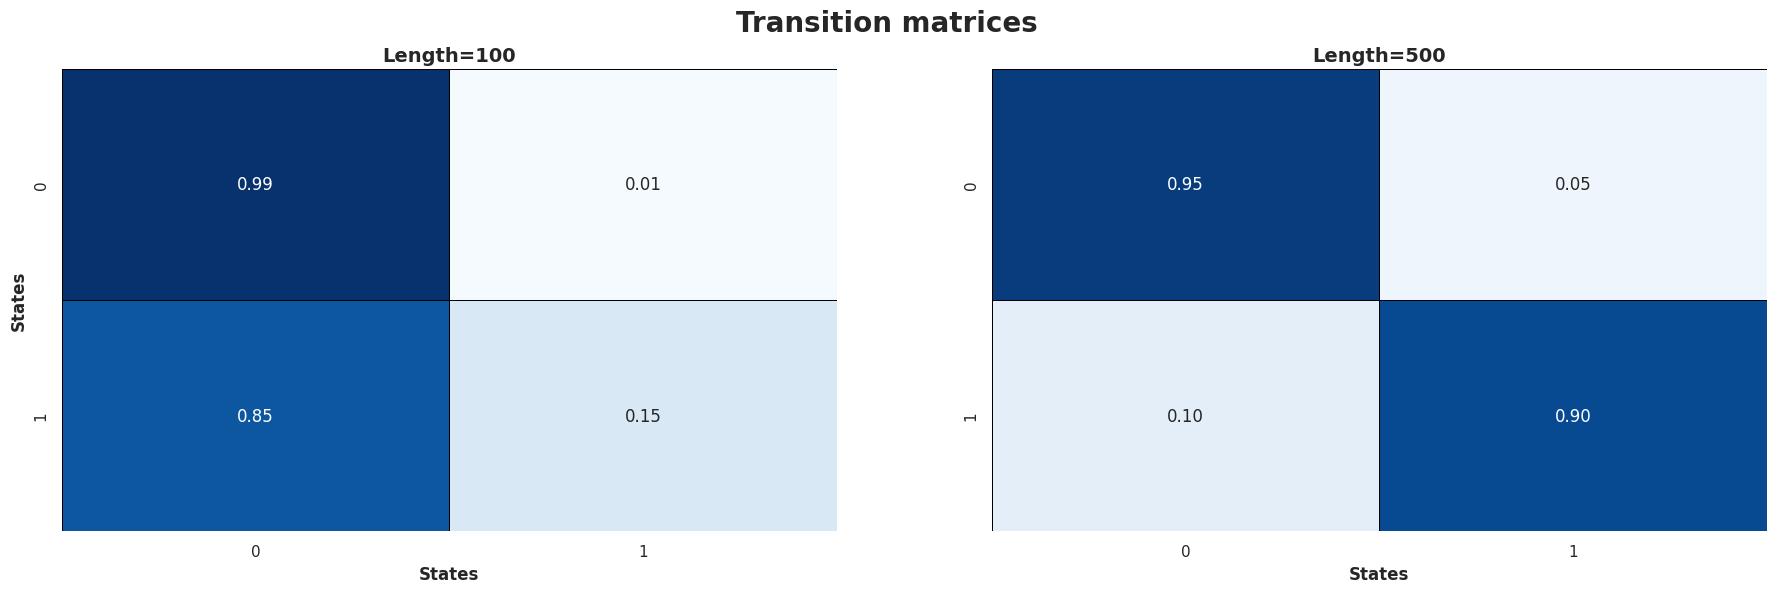

In [365]:
plot_matrices(matrix_eval=[m[:, :, 0] for m in all_M], 
              matrix_gt=M, 
              lengthes=length_seq, 
              title="Transition matrices", 
              ylabel="States", 
              xlabel="States")

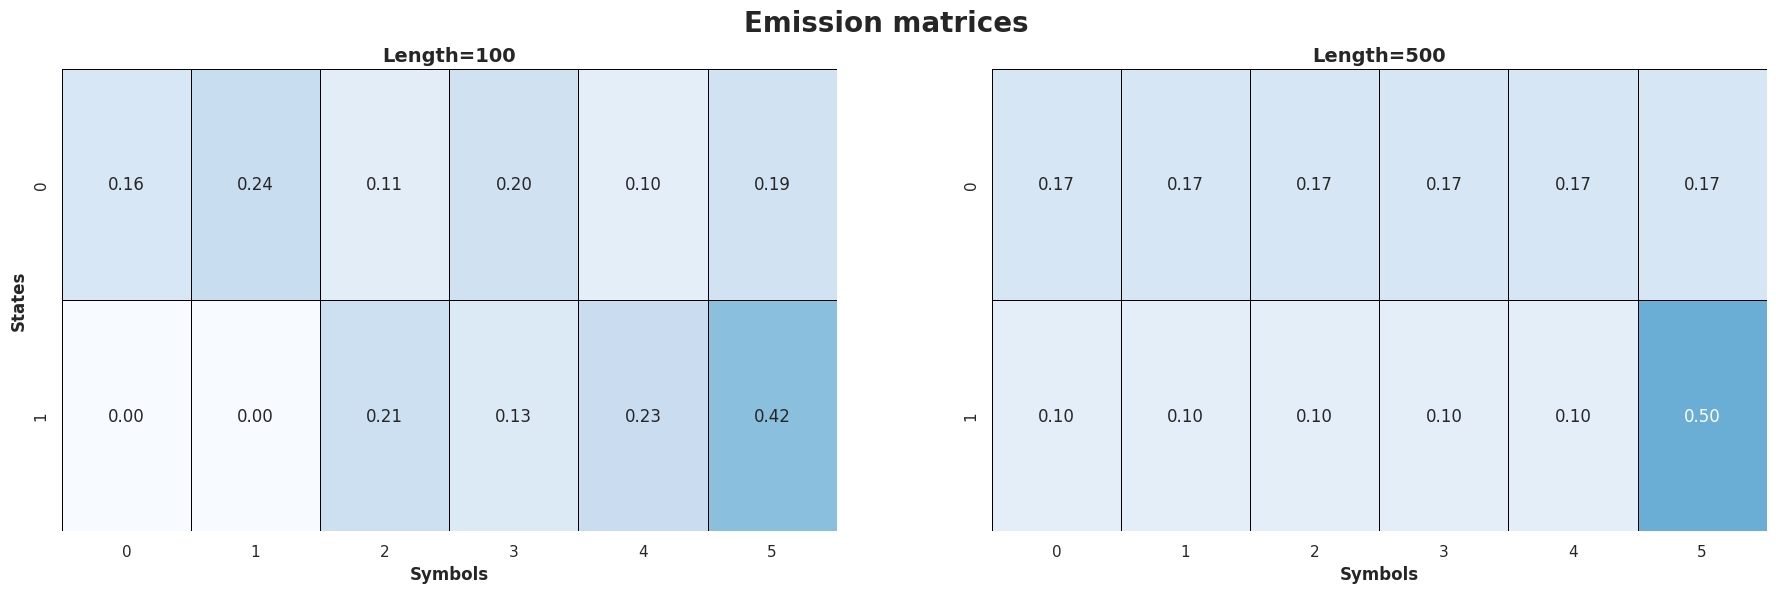

In [366]:
plot_matrices(matrix_eval=all_E, 
              matrix_gt=E, 
              lengthes=length_seq, 
              title="Emission matrices", 
              ylabel="States", 
              xlabel="Symbols")

In [360]:
all_E

[array([[0.04552807, 0.06666667, 0.03529006, 0.05729275, 0.03477238,
         0.04956002],
        [0.00447193, 0.        , 0.00470994, 0.00270725, 0.00522762,
         0.02710664]])]